In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("../outputs/analysis/data_quality/data_quality_summary.csv")
df

print(f"Total samples analyzed: {df['total_samples']}")
print(f"Samples with potential issues: {df['n_label_issues'][0]} ({df['label_issue_rate'][0]*100:.4}%)")



Total samples analyzed: 0    8637
Name: total_samples, dtype: int64
Samples with potential issues: 3722 (43.09%)


# Label Issues Analysis

Confidence in given labels statistics:


{'whiskers': [<matplotlib.lines.Line2D at 0x34a92f880>,
 'caps': [<matplotlib.lines.Line2D at 0x34bcc5670>,
 'boxes': [<matplotlib.lines.Line2D at 0x34bcbfd30>],
 'medians': [<matplotlib.lines.Line2D at 0x34bcc5d60>],
 'fliers': [<matplotlib.lines.Line2D at 0x34c3514f0>],
 'means': []}

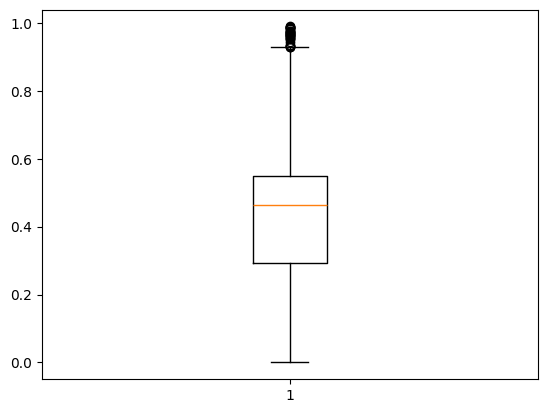

In [11]:
df = pd.read_csv("../outputs/analysis/data_quality/label_issues.csv")
df

print(f"Confidence in given labels statistics:")
plt.boxplot(df['confidence_in_given'], vert=True)





Confidence in suggested labels statistics:


{'whiskers': [<matplotlib.lines.Line2D at 0x34a738580>,
 'caps': [<matplotlib.lines.Line2D at 0x34a738ac0>,
 'boxes': [<matplotlib.lines.Line2D at 0x34a7382e0>],
 'medians': [<matplotlib.lines.Line2D at 0x34a738fd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x34a7472e0>],
 'means': []}

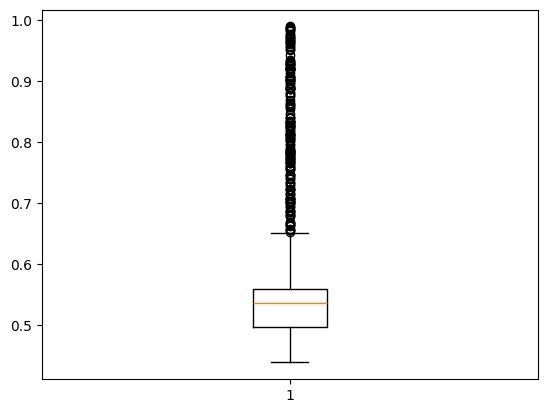

In [4]:
print(f"Confidence in suggested labels statistics:")
plt.boxplot(df['confidence_in_suggested'], vert=True)

Confidence in suggested-given labels statistics:
count    3722.000000
mean        0.121840
std         0.167532
min         0.000000
25%         0.000000
50%         0.000000
75%         0.251429
max         0.682886
Name: confidence_in_suggested_minus_given, dtype: float64


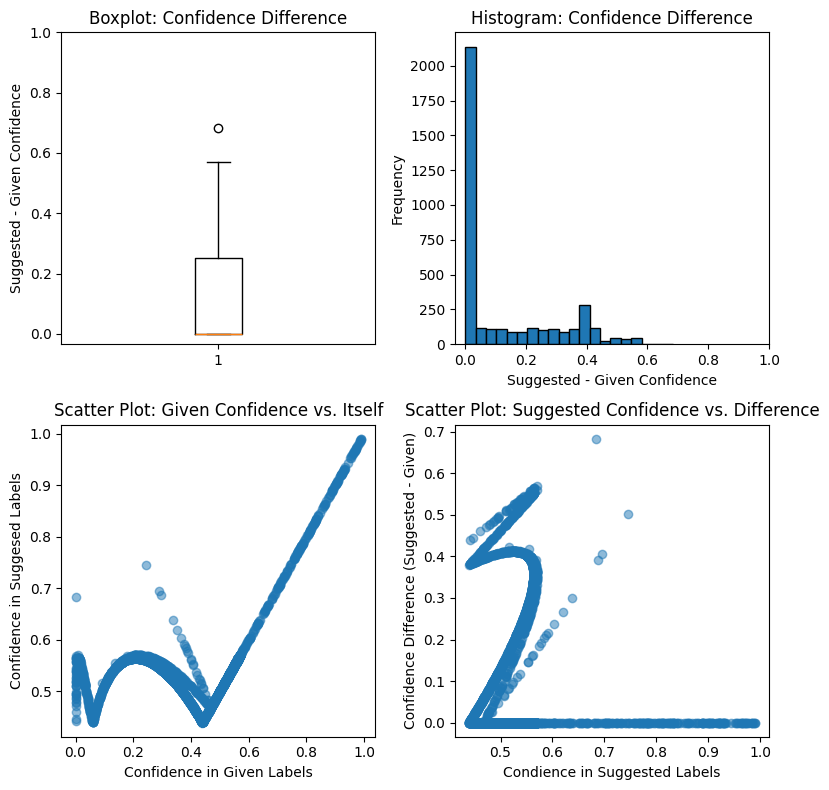

In [12]:

# Load the data
df = pd.read_csv('../outputs/analysis/data_quality/label_issues.csv')

# Calculate the difference
df['confidence_in_suggested_minus_given'] = df['confidence_in_suggested'] - df['confidence_in_given']

# Create a figure with two subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

# Ticks every 0.2
ticks = np.arange(0, 1.1, 0.2)

# Boxplot
ax1.boxplot(df['confidence_in_suggested_minus_given'], vert=True)
ax1.set_yticks(ticks)
ax1.set_title('Boxplot: Confidence Difference')
ax1.set_ylabel('Suggested - Given Confidence')

# Histogram
ax2.hist(df['confidence_in_suggested_minus_given'], bins=20, edgecolor='black')
ax2.set_xticks(ticks)
ax2.set_title('Histogram: Confidence Difference')
ax2.set_xlabel('Suggested - Given Confidence')
ax2.set_ylabel('Frequency')

ax3.scatter(df["confidence_in_given"], df['confidence_in_suggested'], alpha=0.5)
ax3.set_xlabel("Confidence in Given Labels")
ax3.set_ylabel("Confidence in Suggesed Labels")
ax3.set_title("Scatter Plot: Given Confidence vs. Itself")

ax4.scatter(df["confidence_in_suggested"], df['confidence_in_suggested_minus_given'], alpha=0.5)
ax4.set_xlabel("Condience in Suggested Labels")
ax4.set_ylabel("Confidence Difference (Suggested - Given)")
ax4.set_title("Scatter Plot: Suggested Confidence vs. Difference")
plt.tight_layout()
#plt.savefig('confidence_diff_plots.png')

# Output some stats as requested in the user's print statement
stats = df['confidence_in_suggested_minus_given'].describe()
print(f"Confidence in suggested-given labels statistics:\n{stats}")



In [14]:
df[df["confidence_in_suggested_minus_given"] != 0]

,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested,confidence_in_suggested_minus_given
0,175,24409454,10,5,7.623509e-12,0.564127,0.564127
1,1241,24319685,4,8,2.632209e-08,0.557604,0.557604
2,2189,24601200,5,9,3.858338e-08,0.569482,0.569482
3,2021,24319683,5,8,3.769558e-06,0.460325,0.460321
4,363,24601328,10,7,1.332256e-05,0.526212,0.526198
...,...,...,...,...,...,...,...
1808,659,24163856,2,1,4.577485e-01,0.482450,0.024701
1816,510,24086271,10,9,4.589106e-01,0.473670,0.014759
1825,428,23989857,10,9,4.600154e-01,0.472939,0.012923
1855,451,24316234,10,9,4.638278e-01,0.470405,0.006577


In [40]:
top_20_percent = int(0.1 * len(df))
top_diff_samples = df.sort_values('confidence_in_suggested_minus_given', ascending=False).head(top_20_percent)
top_diff_samples



,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested,confidence_in_suggested_minus_given
13,1364,24341712,4,1,1.421736e-04,0.683028,0.682886
2,2189,24601200,5,9,3.858338e-08,0.569482,0.569482
0,175,24409454,10,5,7.623509e-12,0.564127,0.564127
11,342,24143441,10,7,6.704726e-05,0.564109,0.564042
10,2078,24601203,5,8,6.511155e-05,0.564103,0.564038
...,...,...,...,...,...,...,...
342,188,24409451,10,9,1.141445e-01,0.527581,0.413437
343,172,24258497,10,9,1.142043e-01,0.527641,0.413436
176,1263,23703213,4,6,5.004420e-02,0.463480,0.413436
345,183,24406400,10,9,1.144557e-01,0.527889,0.413433


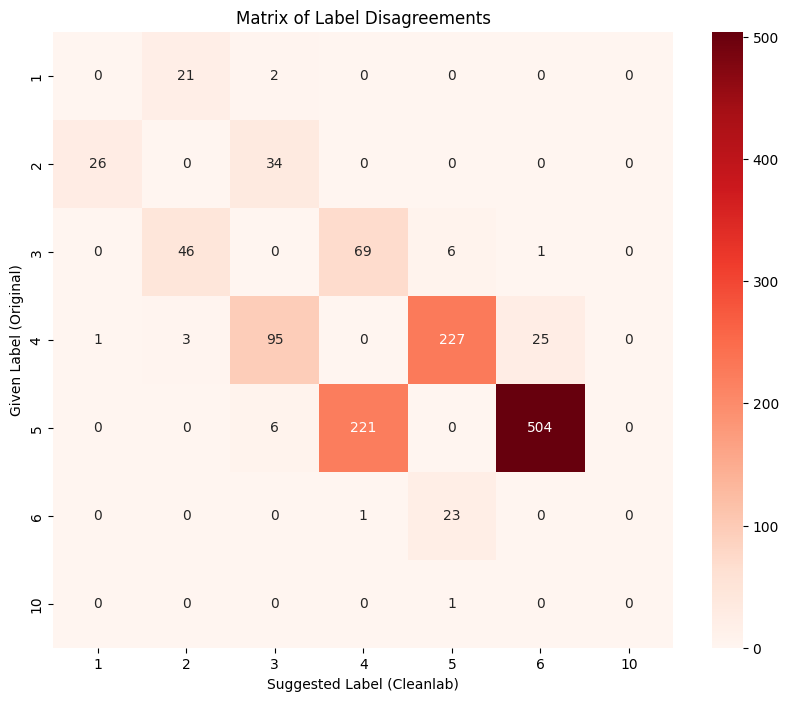

In [23]:
# Filter only for actual disagreements (where given != suggested)
mismatch_df = df[df['given_label'] != df['suggested_label']]

# Create the matrix
labels = sorted(df['given_label'].unique())
cm = confusion_matrix(mismatch_df['given_label'], 
                      mismatch_df['suggested_label'], 
                      labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Suggested Label (Cleanlab)')
plt.ylabel('Given Label (Original)')
plt.title('Matrix of Label Disagreements')
plt.show()

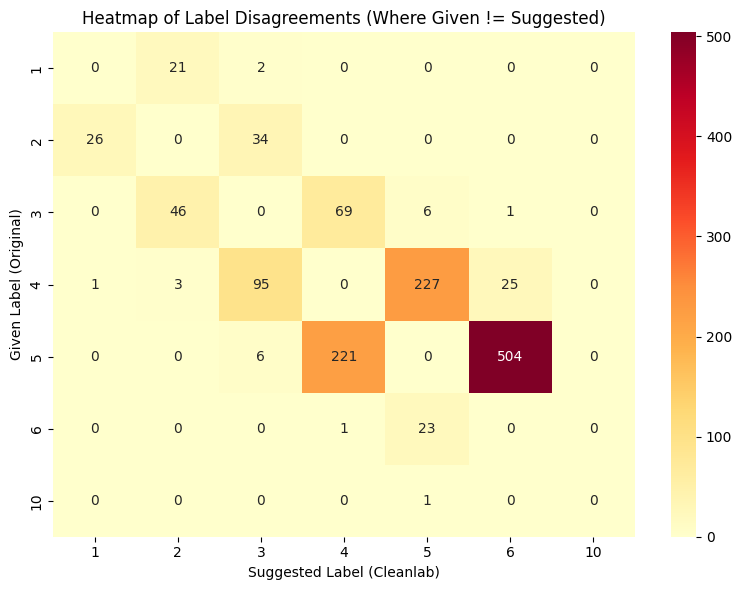

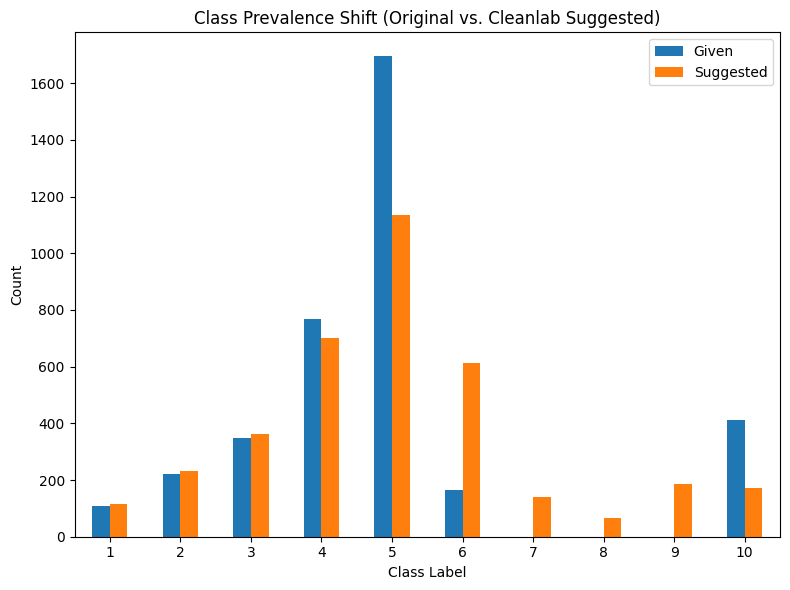

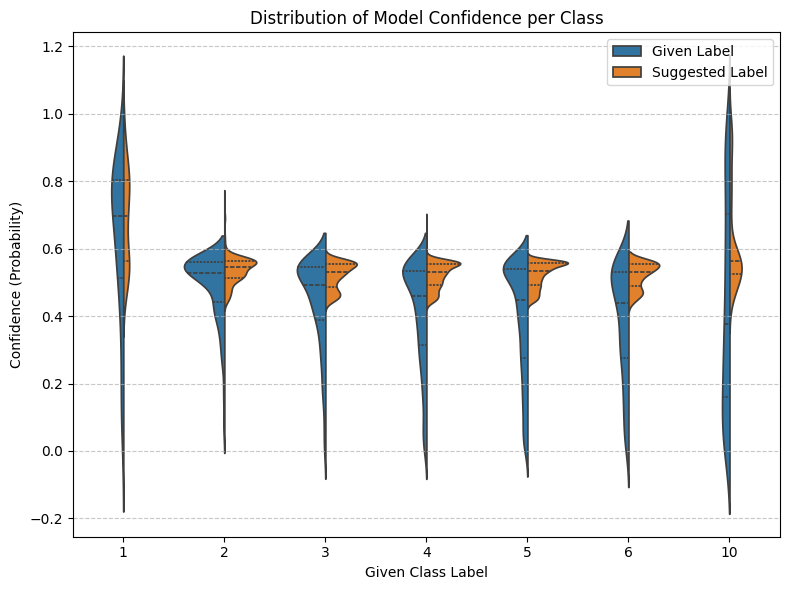

Visualizations generated: disagreement_heatmap.png, prevalence_shift.png, confidence_violin_plots.png


In [31]:


# 1. Heatmap of Disagreements
mismatch_df = df[df['given_label'] != df['suggested_label']]
labels = sorted(df['given_label'].unique())
cm = confusion_matrix(mismatch_df['given_label'], 
                      mismatch_df['suggested_label'], 
                      labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Suggested Label (Cleanlab)')
plt.ylabel('Given Label (Original)')
plt.title('Heatmap of Label Disagreements (Where Given != Suggested)')
plt.tight_layout()
# plt.savefig('disagreement_heatmap.png')
plt.show()
plt.close()

# 2. Class Prevalence Shift
given_counts = df['given_label'].value_counts().sort_index()
# To get the prevalence after cleaning, we assume we replace every issue with suggested_label
# Or more accurately, we compare the total distribution in the original vs the suggested in this subset
suggested_counts = df['suggested_label'].value_counts().sort_index()

prevalence_df = pd.DataFrame({
    'Given': given_counts,
    'Suggested': suggested_counts
}).fillna(0)

prevalence_df.plot(kind='bar', figsize=(8, 6))
plt.title('Class Prevalence Shift (Original vs. Cleanlab Suggested)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
# plt.savefig('prevalence_shift.png')
plt.show()
plt.close()

# 3. Violin Plots of Confidence
plt.figure(figsize=(8, 6))
# Prepare data for violin plot
melted_df = df.melt(id_vars=['given_label'], 
                    value_vars=['confidence_in_given', 'confidence_in_suggested'],
                    var_name='Confidence Type', value_name='Probability')

# Rename for better display
melted_df['Confidence Type'] = melted_df['Confidence Type'].replace({
    'confidence_in_given': 'Given Label',
    'confidence_in_suggested': 'Suggested Label'
})

sns.violinplot(data=melted_df, x='given_label', y='Probability', 
               hue='Confidence Type', split=True, inner="quart")
plt.title('Distribution of Model Confidence per Class')
plt.xlabel('Given Class Label')
plt.ylabel('Confidence (Probability)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
# plt.savefig('confidence_violin_plots.png')
plt.show()
plt.close()

print("Visualizations generated: disagreement_heatmap.png, prevalence_shift.png, confidence_violin_plots.png")

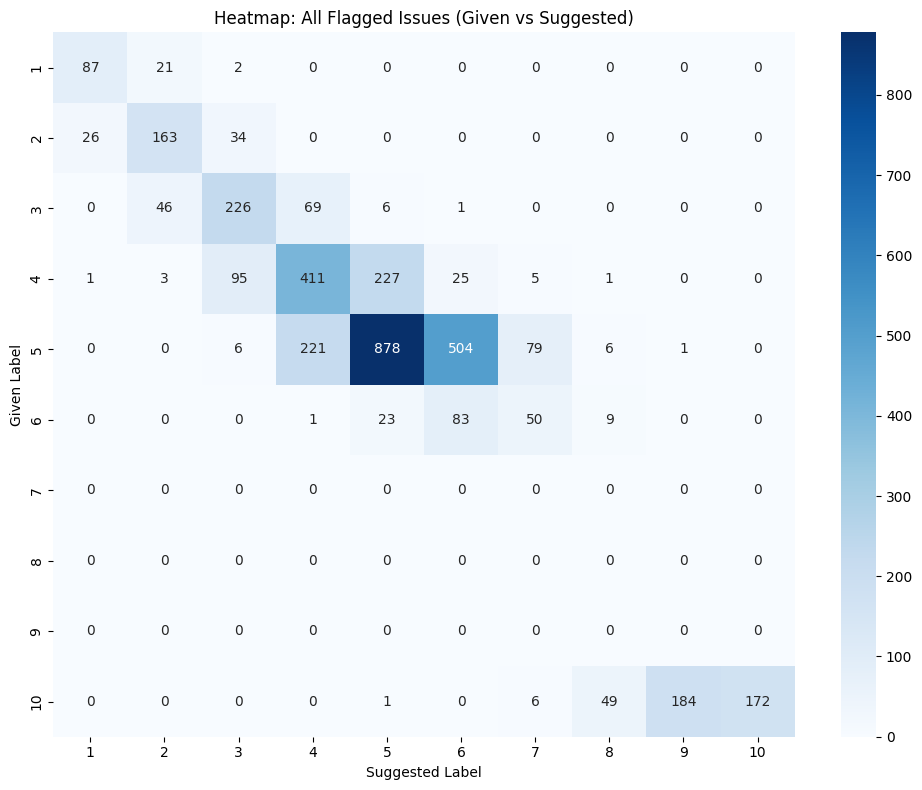

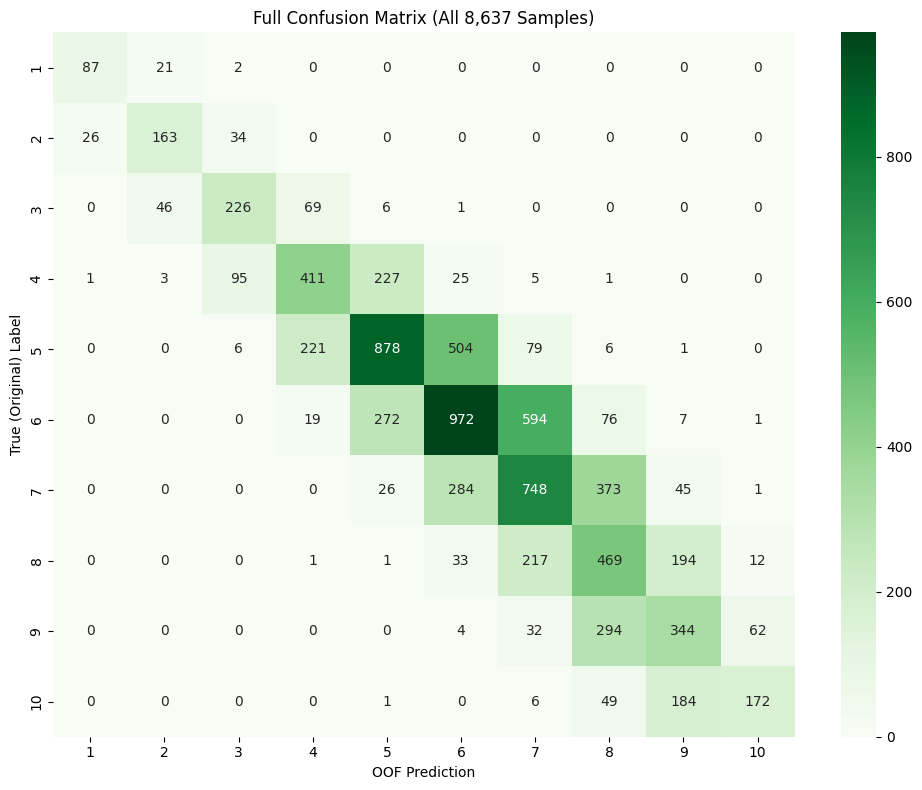

Unique labels in full dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load files
df_issues = df
df_oof = pd.read_csv('../outputs/analysis/data_quality/oof_predictions.csv')

# Let's get the full set of labels present across both files
all_labels = sorted(list(set(df_oof['true_label'].unique()) | set(df_oof['oof_prediction'].unique())))

# 1. Heatmap of ALL Flagged Issues (Including those where Given == Suggested)
cm_issues = confusion_matrix(df_issues['given_label'], 
                             df_issues['suggested_label'], 
                             labels=all_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_issues, annot=True, fmt='d', cmap='Blues', 
            xticklabels=all_labels, yticklabels=all_labels)
plt.title('Heatmap: All Flagged Issues (Given vs Suggested)')
plt.xlabel('Suggested Label')
plt.ylabel('Given Label')
plt.tight_layout()
#plt.savefig('heatmap_all_issues.png')
plt.show()
plt.close()

# 2. Full Confusion Matrix (OOF Predictions for the entire dataset)
cm_full = confusion_matrix(df_oof['true_label'], 
                           df_oof['oof_prediction'], 
                           labels=all_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Greens', 
            xticklabels=all_labels, yticklabels=all_labels)
plt.title('Full Confusion Matrix (All 8,637 Samples)')
plt.xlabel('OOF Prediction')
plt.ylabel('True (Original) Label')
plt.tight_layout()
#plt.savefig('full_confusion_matrix.png')
plt.show()
plt.close()

print(f"Unique labels in full dataset: {all_labels}")

# Visualisase suspicious samples

In [36]:

issues_to_review = top_diff_samples


# 2. Configuration: Update this path to where your images are stored
BASE_PATH = "../otolith_images" 

def get_image_path(row):
    # Adjust file extension (.jpg, .png, etc.) to match your data
    return os.path.join(BASE_PATH, str(int(row['given_label'])), f"{int(row['measurement_id'])}.jpg")

# 3. Viewer Logic
class LabelIssueViewer:
    def __init__(self, data):
        self.data = data
        self.index = 0
        self.output = widgets.Output()
        
        # Buttons
        self.btn_prev = widgets.Button(description="⬅️ Previous")
        self.btn_next = widgets.Button(description="Next ➡️")
        self.btn_prev.on_click(self.prev_image)
        self.btn_next.on_click(self.next_image)
        
    def show(self):
        # Layout: Buttons at the top, Image below
        controls = widgets.HBox([self.btn_prev, self.btn_next])
        display(controls, self.output)
        self.render()

    def render(self):
        with self.output:
            clear_output(wait=True)
            row = self.data.iloc[self.index]
            img_path = get_image_path(row)
            
            # Show Info
            print(f"Reviewing Issue {self.index + 1} of {len(self.data)}")
            print(f"Measurement ID: {row['measurement_id']}")
            print(f"Current Label: {row['given_label']} | Suggested: {row['suggested_label']}")
            print(f"Confidence in Given: {row['confidence_in_given']:.4f} | Confidence in Suggested: {row['confidence_in_suggested']:.4f}")
            print(f"Difference (Suggested - Given): {row['confidence_in_suggested'] - row['confidence_in_given']:.4f}")
            
            # Plot Image
            if os.path.exists(img_path):
                img = plt.imread(img_path)
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.title(f"Label: {row['given_label']} vs Suggestion: {row['suggested_label']}")
                plt.axis('off')
                plt.show()
            else:
                print(f"⚠️ Image not found at: {img_path}")

    def next_image(self, b):
        if self.index < len(self.data) - 1:
            self.index += 1
            self.render()

    def prev_image(self, b):
        if self.index > 0:
            self.index -= 1
            self.render()

# 4. Launch Viewer
viewer = LabelIssueViewer(issues_to_review)
viewer.show()

Output()

## Most Confident Mislabelled Samples Analysis